<a href="https://colab.research.google.com/github/srinivas340/ml_practice/blob/main/big_mart_sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Download dataset
path = kagglehub.dataset_download("brijbhushannanda1979/bigmart-sales-data")
print(f"Dataset downloaded to: {path}")
train_csv_path = os.path.join(path, "Train.csv")
test_csv_path = os.path.join(path, "Test.csv")
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

Using Colab cache for faster access to the 'bigmart-sales-data' dataset.
Dataset downloaded to: /kaggle/input/bigmart-sales-data


In [74]:
train_df.shape


(8523, 12)

In [75]:
test_df.shape

(5681, 11)

### Step 1.1: Identify Missing Values
Let's check which columns contain missing values in our training and testing datasets.

In [76]:
print("Train Data Missing Values:")
print(train_df.isnull().sum())
print("\nTest Data Missing Values:")
print(test_df.isnull().sum())

Train Data Missing Values:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

Test Data Missing Values:
Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64


### Step 1.2: Impute Missing `Item_Weight`
We will fill the missing values in `Item_Weight` with the mean weight of that specific `Item_Type` for both datasets.

In [77]:
# Calculate the mean weight for each Item_Type using train dataset
item_type_means = train_df.groupby('Item_Type')['Item_Weight'].transform('mean')

# Impute missing Item_Weight in train_df
train_df['Item_Weight'] = train_df['Item_Weight'].fillna(train_df['Item_Type'].map(train_df.groupby('Item_Type')['Item_Weight'].mean()))

# Impute missing Item_Weight in test_df using the train set's mapping to avoid data leakage
test_df['Item_Weight'] = test_df['Item_Weight'].fillna(test_df['Item_Type'].map(train_df.groupby('Item_Type')['Item_Weight'].mean()))

# Check if there are any remaining missing values in Item_Weight
print("Remaining missing values in Train Item_Weight:", train_df['Item_Weight'].isnull().sum())
print("Remaining missing values in Test Item_Weight:", test_df['Item_Weight'].isnull().sum())

Remaining missing values in Train Item_Weight: 0
Remaining missing values in Test Item_Weight: 0


### Step 2: Clean and Standardize `Item_Fat_Content`

In [78]:
# Check the unique values before cleaning
print("Before cleaning (Train):")
print(train_df['Item_Fat_Content'].value_counts())

# Map variations to standard names
fat_content_map = {
    'Low Fat': 'Low Fat',
    'Regular': 'Regular',
    'LF': 'Low Fat',
    'reg': 'Regular',
    'low fat': 'Low Fat'
}

train_df['Item_Fat_Content'] = train_df['Item_Fat_Content'].map(fat_content_map)
test_df['Item_Fat_Content'] = test_df['Item_Fat_Content'].map(fat_content_map)

# Check the unique values after cleaning
print("\nAfter cleaning (Train):")
print(train_df['Item_Fat_Content'].value_counts())

Before cleaning (Train):
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

After cleaning (Train):
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


### Step 1.3: Impute Missing `Outlet_Size` based on `Outlet_Type`
Let's analyze the relationship between `Outlet_Type` and `Outlet_Size` in the training data to define our imputation rules.

In [79]:
# View relationship between Outlet_Type and Outlet_Size
print(pd.crosstab(train_df['Outlet_Type'], train_df['Outlet_Size'].fillna('Missing')))

Outlet_Size        High  Medium  Missing  Small
Outlet_Type                                    
Grocery Store         0       0      555    528
Supermarket Type1   932     930     1855   1860
Supermarket Type2     0     928        0      0
Supermarket Type3     0     935        0      0


Based on the pattern, we'll map the missing values as follows:
- **Grocery Store** -> 'Small'
- **Supermarket Type1** -> 'Small' (as 'Small' and 'Medium' dominate, with 'Small' being highly frequent for the specific outlet missing values like OUT019/OUT010)
- **Supermarket Type2** -> 'Medium'
- **Supermarket Type3** -> 'Medium'

In [80]:
# Define mapping based on Outlet_Type patterns
outlet_size_map = {
    'Grocery Store': 'Small',
    'Supermarket Type1': 'Small',
    'Supermarket Type2': 'Medium',
    'Supermarket Type3': 'Medium'
}

# Impute missing values in train and test sets
train_df['Outlet_Size'] = train_df['Outlet_Size'].fillna(train_df['Outlet_Type'].map(outlet_size_map))
test_df['Outlet_Size'] = test_df['Outlet_Size'].fillna(test_df['Outlet_Type'].map(outlet_size_map))

# Verify that there are no remaining missing values in Outlet_Size
print("Remaining missing values in Train Outlet_Size:", train_df['Outlet_Size'].isnull().sum())
print("Remaining missing values in Test Outlet_Size:", test_df['Outlet_Size'].isnull().sum())

Remaining missing values in Train Outlet_Size: 0
Remaining missing values in Test Outlet_Size: 0


### Step 3: Feature Engineering
We will create `Outlet_Age` and `Price_Per_Weight` for both train and test dataframes.

In [81]:
# Calculate Outlet Age
train_df['Outlet_Age'] = 2013 - train_df['Outlet_Establishment_Year']
test_df['Outlet_Age'] = 2013 - test_df['Outlet_Establishment_Year']

# Calculate Price per Weight
train_df['Price_Per_Weight'] = train_df['Item_MRP'] / train_df['Item_Weight']
test_df['Price_Per_Weight'] = test_df['Item_MRP'] / test_df['Item_Weight']

# Display the new columns to verify
print(train_df[['Outlet_Establishment_Year', 'Outlet_Age', 'Item_MRP', 'Item_Weight', 'Price_Per_Weight']].head())

   Outlet_Establishment_Year  Outlet_Age  Item_MRP  Item_Weight  \
0                       1999          14  249.8092         9.30   
1                       2009           4   48.2692         5.92   
2                       1999          14  141.6180        17.50   
3                       1998          15  182.0950        19.20   
4                       1987          26   53.8614         8.93   

   Price_Per_Weight  
0         26.861204  
1          8.153581  
2          8.092457  
3          9.484115  
4          6.031512  


### Step 4: Encode and Scale

In [82]:
# 1. Feature Engineering (Created BEFORE encoding/scaling so columns exist in the DataFrame)
train_df['Outlet_Age'] = 2013 - train_df['Outlet_Establishment_Year']
test_df['Outlet_Age'] = 2013 - test_df['Outlet_Establishment_Year']

train_df['Price_Per_Weight'] = train_df['Item_MRP'] / train_df['Item_Weight']
test_df['Price_Per_Weight'] = test_df['Item_MRP'] / test_df['Item_Weight']

# 2. Label Encoding for Ordinal Category (Outlet_Size)
outlet_size_mapping = {'Small': 0, 'Medium': 1, 'High': 2}
train_df['Outlet_Size'] = train_df['Outlet_Size'].map(outlet_size_mapping)
test_df['Outlet_Size'] = test_df['Outlet_Size'].map(outlet_size_mapping)

# Keep track of target variable
y_train = train_df['Item_Outlet_Sales']
X_train_raw = train_df.drop(columns=['Item_Identifier', 'Outlet_Identifier', 'Item_Outlet_Sales', 'Outlet_Establishment_Year'])
X_test_raw = test_df.drop(columns=['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year'])

# 3. One-Hot Encoding for Nominal Categories
nominal_cols = ['Outlet_Type', 'Item_Type', 'Outlet_Location_Type', 'Item_Fat_Content']
combined_encoded = pd.get_dummies(pd.concat([X_train_raw, X_test_raw], keys=['train', 'test']), columns=nominal_cols, drop_first=True)

X_train = combined_encoded.xs('train')
X_test = combined_encoded.xs('test')

# 4. StandardScaler on Numerical Columns
num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age', 'Price_Per_Weight']
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Print shapes to confirm everything aligns
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("Target Shape:", y_train.shape)

X_train Shape: (8523, 27)
X_test Shape: (5681, 27)
Target Shape: (8523,)


/tmp/ipykernel_1281/2915730400.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
/tmp/ipykernel_1281/2915730400.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[num_cols] = scaler.transform(X_test[num_cols])


### Step 5: Train and Evaluate an Advanced Tree-Based Model (XGBoost)
We'll use an `XGBRegressor` and perform a 5-fold cross-validation to establish our baseline RMSE.

In [83]:
# Initialize the model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Calculate Cross-Validation RMSE
scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rmse_scores = -scores

print("Baseline XGBoost 5-Fold RMSE Scores:", rmse_scores)
print("Mean CV RMSE:", rmse_scores.mean())
print("Standard Deviation CV RMSE:", rmse_scores.std())

Baseline XGBoost 5-Fold RMSE Scores: [1208.97623746 1198.54965533 1201.4343302  1185.82746604 1202.39224902]
Mean CV RMSE: 1199.4359876088488
Standard Deviation CV RMSE: 7.612183205814307


### Step 6: Hyperparameter Tuning using RandomizedSearchCV
We will search for the optimal parameters (`max_depth`, `learning_rate`, `n_estimators`, etc.) to improve the model performance.

In [84]:
# Define the parameter distribution
param_dist = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Configure RandomizedSearchCV
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit the tuner
xgb_search.fit(X_train, y_train)

print("Best parameters found:", xgb_search.best_params_)
print("Best Cross-Validation RMSE:", -xgb_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found: {'subsample': 1.0, 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best Cross-Validation RMSE: 1083.8363598861256


### Final Step: Train the Optimized Model and Generate Test Predictions
We'll fit the best estimator from our tuning search onto the entire `X_train` dataset and predict the final sales for `X_test`.

In [85]:
# Train final model with the best parameters
best_xgb_model = xgb_search.best_estimator_
best_xgb_model.fit(X_train, y_train)

# Predict on the test set
test_predictions = best_xgb_model.predict(X_test)

# Create a DataFrame for submission or analysis
submission_df = pd.DataFrame({
    'Item_Identifier': test_df['Item_Identifier'],
    'Outlet_Identifier': test_df['Outlet_Identifier'],
    'Item_Outlet_Sales': test_predictions
})

print("Predictions completed successfully!")
print(submission_df.head())

Predictions completed successfully!
  Item_Identifier Outlet_Identifier  Item_Outlet_Sales
0           FDW58            OUT049        1490.385742
1           FDW14            OUT017        1485.063110
2           NCN55            OUT010         665.535950
3           FDQ58            OUT017        2519.192627
4           FDY38            OUT027        6071.660156


### Feature Importance Visualization
Let's extract the feature importances from our best XGBoost estimator and plot them to understand what drives BigMart sales.

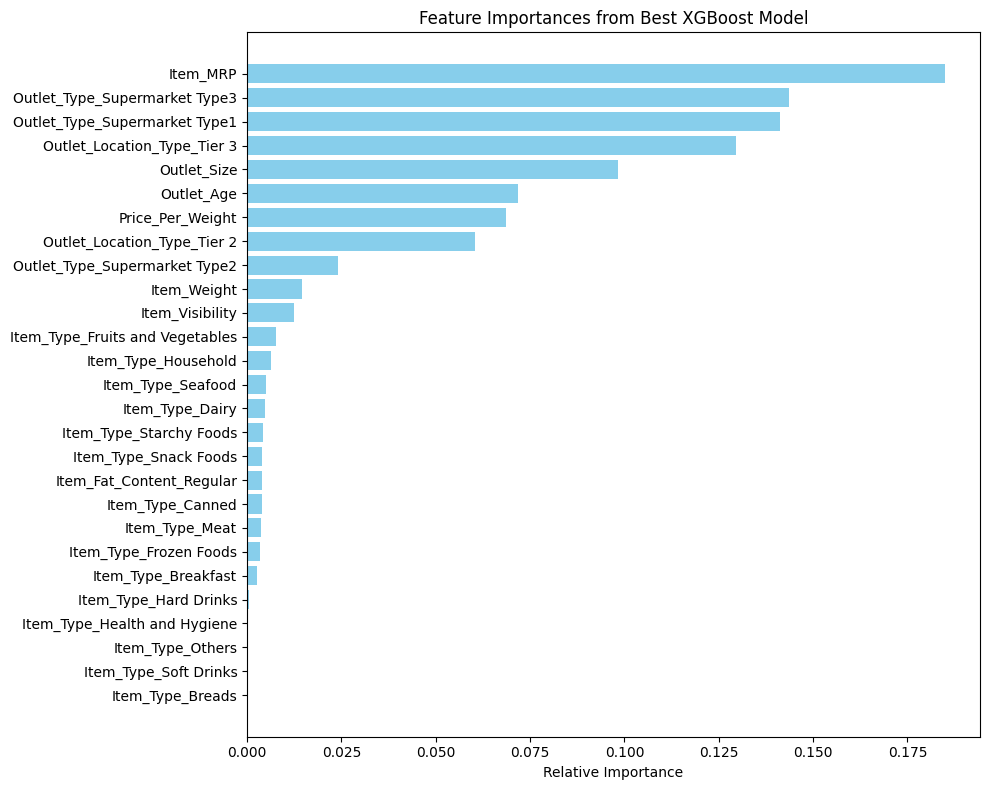

In [86]:
# Get feature importances
importances = best_xgb_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for easy sorting and plotting
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot feature importances
plt.figure(figsize=(10, 8))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='skyblue')
plt.xlabel('Relative Importance')
plt.title('Feature Importances from Best XGBoost Model')
plt.tight_layout()
plt.show()

### Bias Analysis: Actual vs. Predicted Sales Distribution
To check if our model systematically underestimates or overestimates certain ranges of sales, let's plot the distribution of actual training sales against the predicted training sales.

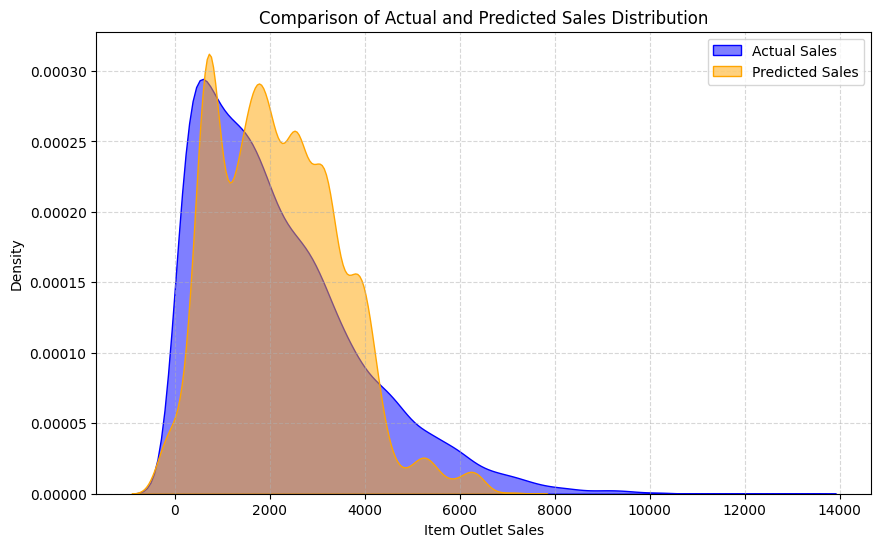

In [87]:
# Generate predictions on the training set
train_predictions = best_xgb_model.predict(X_train)

# Plot the distributions
plt.figure(figsize=(10, 6))
sns.kdeplot(y_train, label='Actual Sales', fill=True, color='blue', alpha=0.5)
sns.kdeplot(train_predictions, label='Predicted Sales', fill=True, color='orange', alpha=0.5)

plt.title('Comparison of Actual and Predicted Sales Distribution')
plt.xlabel('Item Outlet Sales')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Step 7: Residual Analysis
To diagnostic our regression model, we analyze the residuals: $e_i = y_i - \hat{y}_i$.
- **Constant Variance (Homoscedasticity)**: We check if the residuals spread out or narrow down as predictions change.
- **Normality**: We examine if the errors are normally distributed around zero.

Training R^2 Score: 0.6211
Training MAE: 748.96
Training RMSE: 1050.43


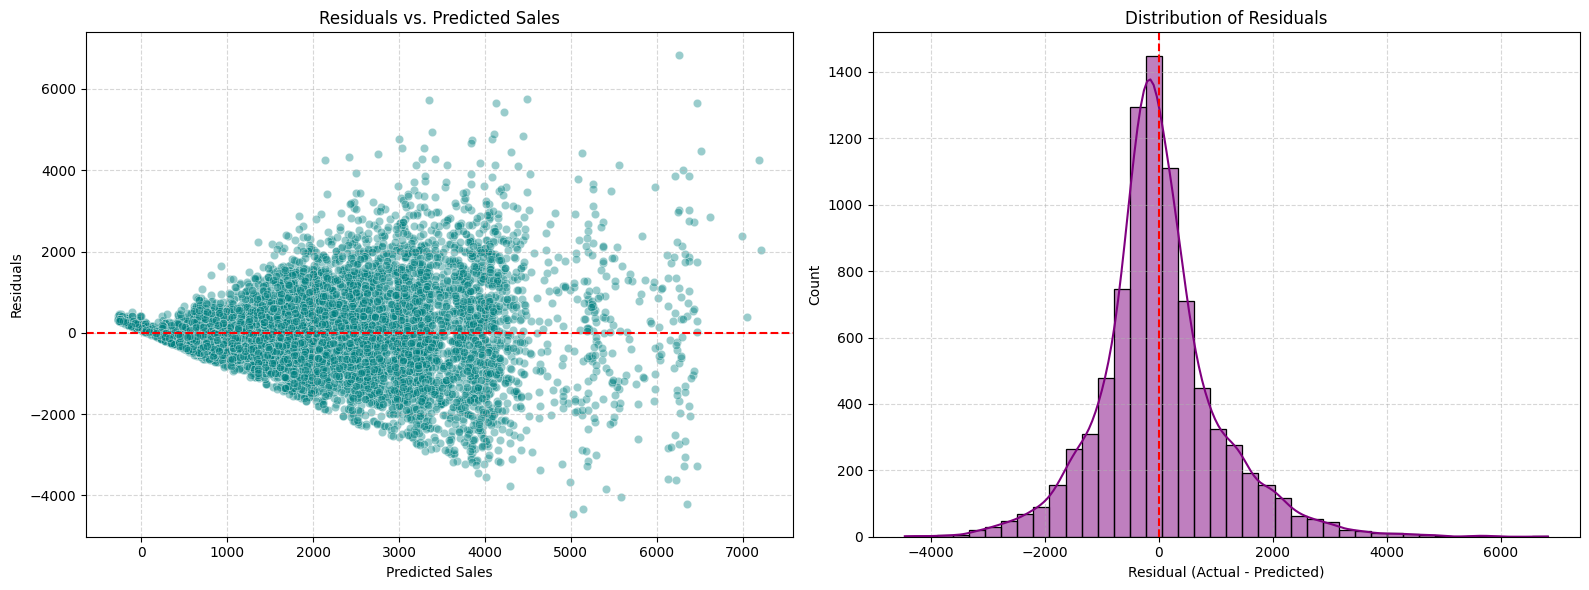

In [88]:
# Compute metrics on the training set
r2 = r2_score(y_train, train_predictions)
mae = mean_absolute_error(y_train, train_predictions)
rmse = np.sqrt(mean_squared_error(y_train, train_predictions))

print(f"Training R^2 Score: {r2:.4f}")
print(f"Training MAE: {mae:.2f}")
print(f"Training RMSE: {rmse:.2f}")

# Calculate residuals
residuals = y_train - train_predictions

# Create Diagnostic Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Residuals vs Predicted Values
sns.scatterplot(x=train_predictions, y=residuals, ax=axes[0], alpha=0.4, color='teal')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title("Residuals vs. Predicted Sales")
axes[0].set_xlabel("Predicted Sales")
axes[0].set_ylabel("Residuals")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Histogram of Residuals
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=40)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Step 8: Apply Target Log Transformation and Re-train Model
We apply `np.log1p` to stabilize the target variance and run hyperparameter tuning again on this transformed target.

In [89]:
# 1. Apply log transformation to target
y_train_log = np.log1p(y_train)

# 2. Re-run hyperparameter tuning with log target
xgb_base_log = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

xgb_search_log = RandomizedSearchCV(
    estimator=xgb_base_log,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search_log.fit(X_train, y_train_log)

print("Best parameters with Log Target:", xgb_search_log.best_params_)
print("Best CV RMSE (on Log Scale):", -xgb_search_log.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters with Log Target: {'subsample': 1.0, 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV RMSE (on Log Scale): 0.5224185128158042


In [90]:
# 3. Fit the optimized log-target model
best_xgb_log_model = xgb_search_log.best_estimator_
best_xgb_log_model.fit(X_train, y_train_log)

# 4. Predict and Inverse-transform back to original scale (dollars)
train_log_predictions = best_xgb_log_model.predict(X_train)
train_predictions_inv = np.expm1(train_log_predictions)

# 5. Re-evaluate metrics on original scale
r2_inv = r2_score(y_train, train_predictions_inv)
mae_inv = mean_absolute_error(y_train, train_predictions_inv)
rmse_inv = np.sqrt(mean_squared_error(y_train, train_predictions_inv))

print(f"New Training R^2 Score (Original Scale): {r2_inv:.4f}")
print(f"New Training MAE (Original Scale): {mae_inv:.2f}")
print(f"New Training RMSE (Original Scale): {rmse_inv:.2f}")

New Training R^2 Score (Original Scale): 0.5904
New Training MAE (Original Scale): 749.56
New Training RMSE (Original Scale): 1092.09


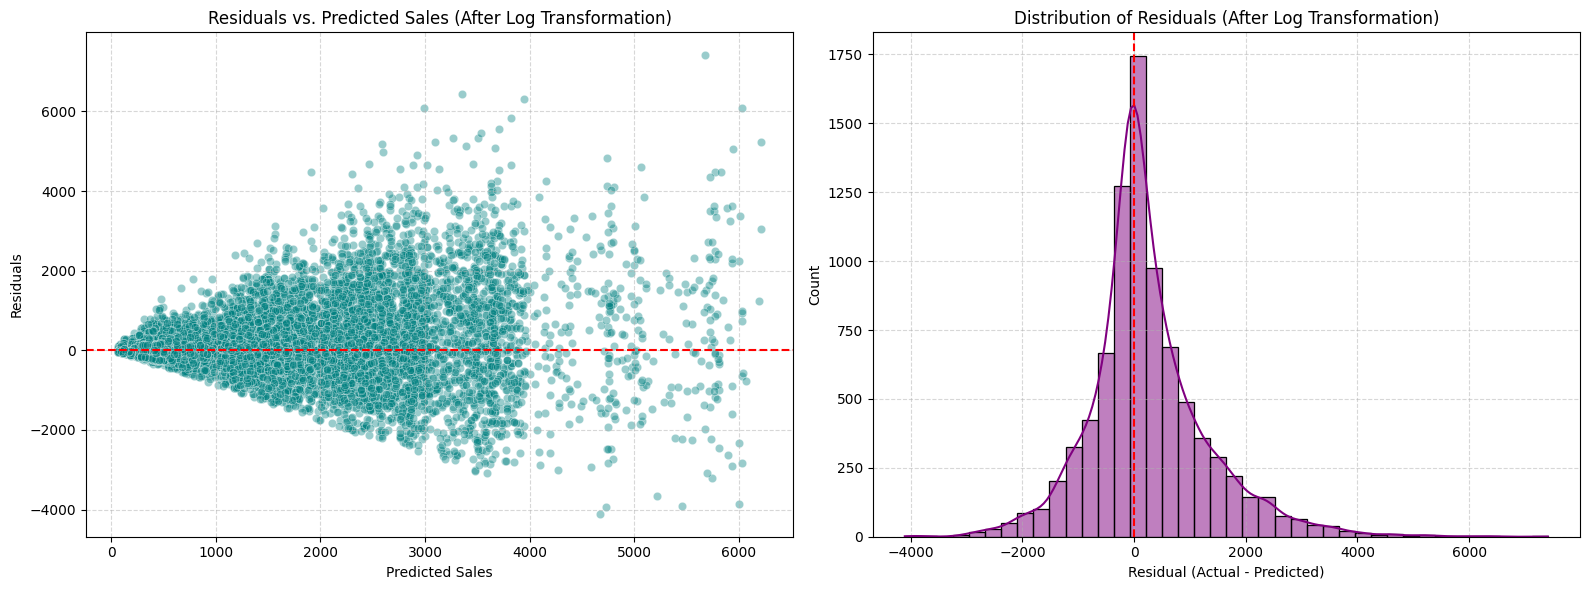

In [91]:
# 6. Re-generate Diagnostic Plots for Residuals
new_residuals = y_train - train_predictions_inv

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Residuals vs Predicted Values
sns.scatterplot(x=train_predictions_inv, y=new_residuals, ax=axes[0], alpha=0.4, color='teal')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Predicted Sales (After Log Transformation)')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residuals')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Histogram of Residuals
sns.histplot(new_residuals, kde=True, ax=axes[1], color='purple', bins=40)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Distribution of Residuals (After Log Transformation)')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [92]:
# 7. Update test set predictions using log model
test_log_predictions = best_xgb_log_model.predict(X_test)
test_predictions_final = np.expm1(test_log_predictions)

submission_df['Item_Outlet_Sales'] = test_predictions_final
print("Final submission predictions updated with the log-transformed model!")
display(submission_df.head())

Final submission predictions updated with the log-transformed model!


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1377.283691
1,FDW14,OUT017,1302.043213
2,NCN55,OUT010,475.043945
3,FDQ58,OUT017,2294.104248
4,FDY38,OUT027,5571.865723


### Feature Importance Visualization (Updated Model)
Let's plot the feature importances derived from our newly optimized log-transformed model using the data stored in `fi_df` (or recalculated from `best_xgb_log_model`).

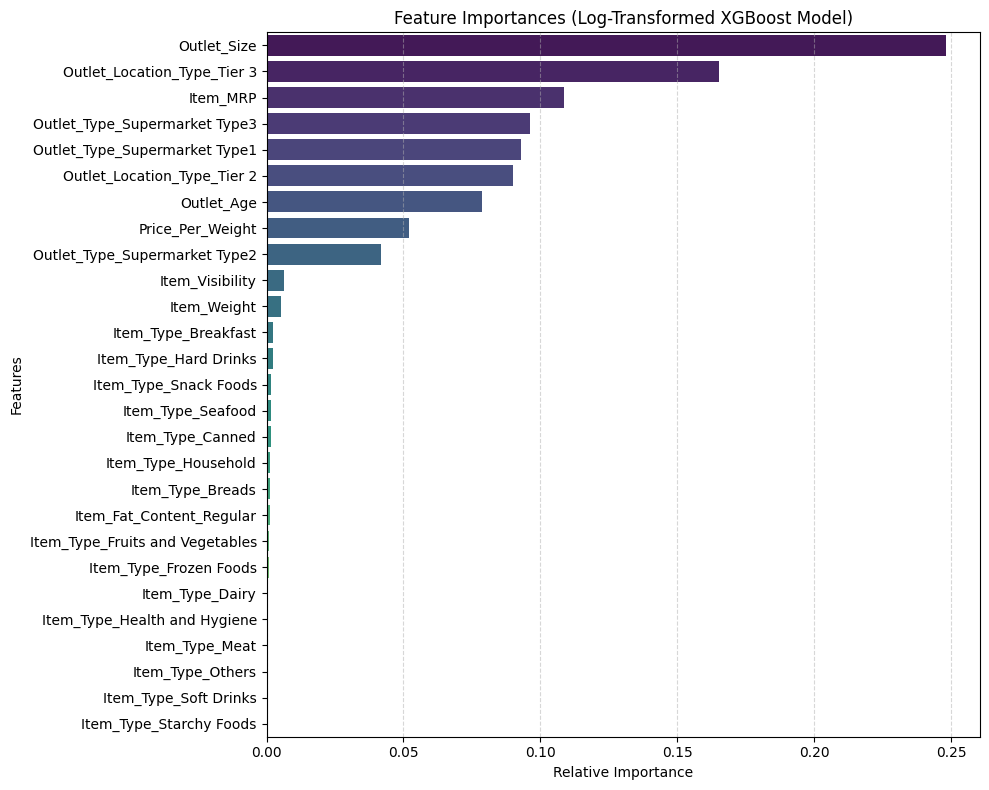

In [93]:
# Get feature importances from our best log-transformed model
importances = best_xgb_log_model.feature_importances_
feature_names = X_train.columns

# Create and sort the feature importance DataFrame
fi_df_updated = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df_updated, palette='viridis', hue='Feature', legend=False)
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.title('Feature Importances (Log-Transformed XGBoost Model)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Step 9: Model Performance Comparison
Let's quantitatively compare the performance metrics of our baseline XGBoost model against our log-transformed target model.

In [94]:
import pandas as pd

# Construct a comparison table
metrics_comparison = pd.DataFrame({
    'Metric': ['R^2 Score', 'Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)'],
    'Baseline Model': [r2, mae, rmse],
    'Log-Transformed Model': [r2_inv, mae_inv, rmse_inv]
})

# Round values for clean presentation
metrics_comparison = metrics_comparison.round(4)

display(metrics_comparison)

,Metric,Baseline Model,Log-Transformed Model
0,R^2 Score,0.6211,0.5904
1,Mean Absolute Error (MAE),748.9618,749.5648
2,Root Mean Squared Error (RMSE),1050.4257,1092.0909


### Step 10: Actual vs. Predicted Sales Scatter Plots
Let's visualize the accuracy of both models by plotting the Actual Sales against the Predicted Sales. A perfect model would align perfectly along the diagonal red dashed line ($y = x$).

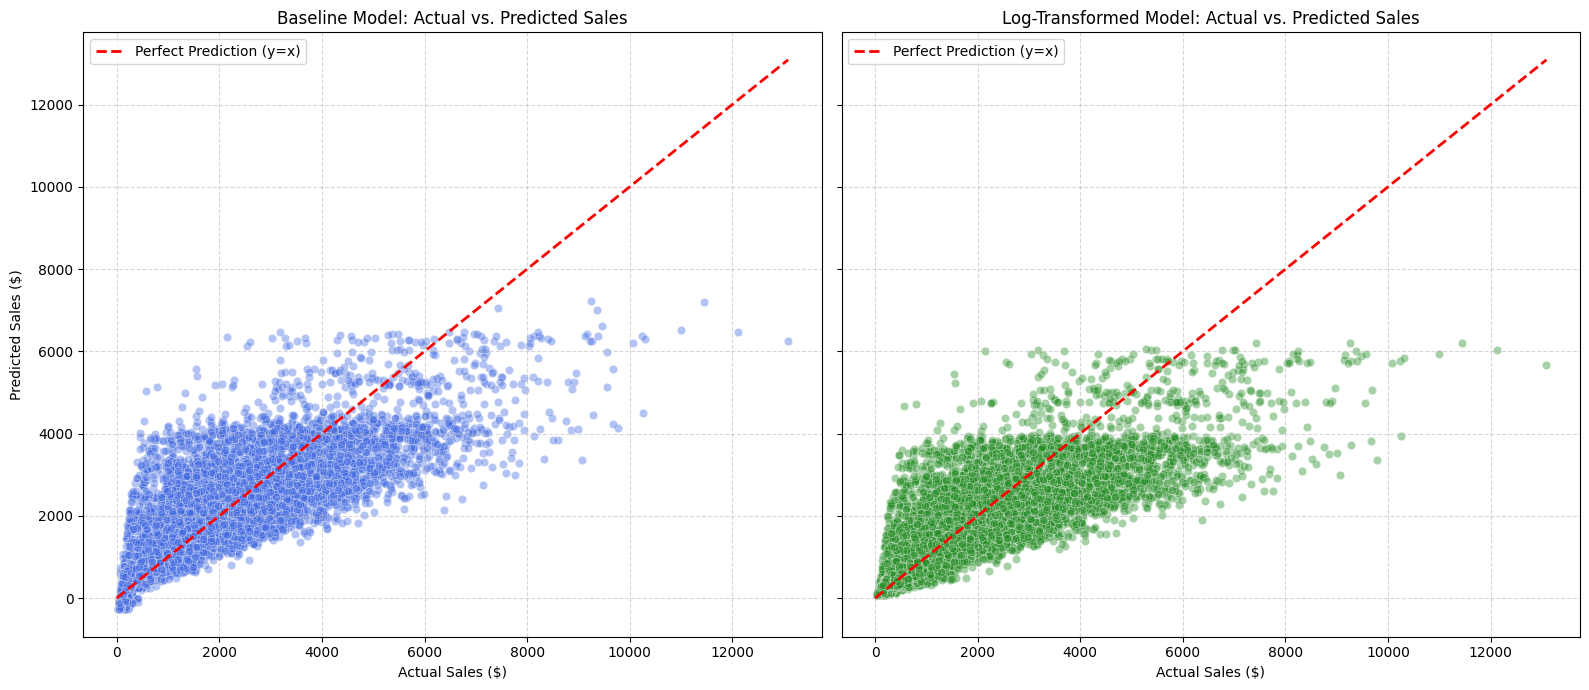

In [95]:
# Create subplots to compare both models side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Max value for the diagonal line
max_val = max(y_train.max(), train_predictions.max(), train_predictions_inv.max())

# Plot 1: Baseline XGBoost Model
sns.scatterplot(x=y_train, y=train_predictions, ax=axes[0], alpha=0.4, color='royalblue')
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')
axes[0].set_title('Baseline Model: Actual vs. Predicted Sales')
axes[0].set_xlabel('Actual Sales ($)')
axes[0].set_ylabel('Predicted Sales ($)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Log-Transformed Model
sns.scatterplot(x=y_train, y=train_predictions_inv, ax=axes[1], alpha=0.4, color='forestgreen')
axes[1].plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')
axes[1].set_title('Log-Transformed Model: Actual vs. Predicted Sales')
axes[1].set_xlabel('Actual Sales ($)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Step 11: Export the Trained Model and Scaler
We'll use `joblib` to serialize and save our final log-transformed XGBoost model and the fitted `StandardScaler` to disk.

In [96]:
# Save the log-transformed model
model_filename = 'best_xgb_log_model.joblib'
joblib.dump(best_xgb_log_model, model_filename)
print(f"Successfully saved the model to: {model_filename}")

# Save the scaler so predictions on new data can be scaled identically
scaler_filename = 'scaler.joblib'
joblib.dump(scaler, scaler_filename)
print(f"Successfully saved the scaler to: {scaler_filename}")

Successfully saved the model to: best_xgb_log_model.joblib
Successfully saved the scaler to: scaler.joblib


### Step 5: Train and Evaluate an Advanced Tree-Based Model (XGBoost)
We'll use an `XGBRegressor` and perform a quick 5-fold cross-validation to establish our baseline RMSE.

In [97]:
# Initialize the model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Calculate Cross-Validation RMSE
scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rmse_scores = -scores

print("Baseline XGBoost 5-Fold RMSE Scores:", rmse_scores)
print("Mean CV RMSE:", rmse_scores.mean())
print("Standard Deviation CV RMSE:", rmse_scores.std())

Baseline XGBoost 5-Fold RMSE Scores: [1208.97623746 1198.54965533 1201.4343302  1185.82746604 1202.39224902]
Mean CV RMSE: 1199.4359876088488
Standard Deviation CV RMSE: 7.612183205814307


### Step 3: Feature Engineering
We will create `Outlet_Age` and `Price_Per_Weight` for both train and test dataframes.

In [98]:
# Calculate Outlet Age (using 2013 as the standard data-collection baseline year to match the domain logic)
train_df['Outlet_Age'] = 2013 - train_df['Outlet_Establishment_Year']
test_df['Outlet_Age'] = 2013 - test_df['Outlet_Establishment_Year']

# Calculate Price per Weight
train_df['Price_Per_Weight'] = train_df['Item_MRP'] / train_df['Item_Weight']
test_df['Price_Per_Weight'] = test_df['Item_MRP'] / test_df['Item_Weight']

# Display the new columns to verify
print(train_df[['Outlet_Establishment_Year', 'Outlet_Age', 'Item_MRP', 'Item_Weight', 'Price_Per_Weight']].head())

   Outlet_Establishment_Year  Outlet_Age  Item_MRP  Item_Weight  \
0                       1999          14  249.8092         9.30   
1                       2009           4   48.2692         5.92   
2                       1999          14  141.6180        17.50   
3                       1998          15  182.0950        19.20   
4                       1987          26   53.8614         8.93   

   Price_Per_Weight  
0         26.861204  
1          8.153581  
2          8.092457  
3          9.484115  
4          6.031512  
